**YOUR NAME**

CS 252: Mathematical Data Analysis and Visualization


# Lab 4b | Principal Component Analysis


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors
import pandas as pd

plt.style.use(['seaborn-v0_8-colorblind', 'seaborn-v0_8-darkgrid'])
plt.rcParams.update({'font.size': 10})
plt.rcParams.update({'figure.figsize': [6,6]})

np.set_printoptions(suppress=True, precision=5)

## Task 1: Load and preprocess data

We are using the [Wisconsin Breast Cancer dataset](<https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+(Original)>) this week. We will use principal component analysis (PCA) to gain insight about the structure of the dataset.

1. Import dataset using pandas [read_csv](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html) to create a Dataframe from the url: https://raw.githubusercontent.com/patrickmlong/Breast-Cancer-Wisconsin-Diagnostic-DataSet/master/data.csv
2. Create a `cancer_x` DataFrame which includes all of the columns that have the word "mean" in the title (_there should be 10 in total_).
3. Print out a summary of the `cancer_x` DataFrame.
4. Update `cancer_x` so that each variable is min-max normalized. Print out a summary of the updated DataFrame.
5. `diagnosis` is a categorical variable (`M` stands for "malignant" and `B` stands for "benign"). Create a `cancer_y` Series with from the column `diagnosis` and convert the data type to [categorical](https://pandas.pydata.org/docs/user_guide/categorical.html).
   1. In Task 2 of this lab you will use `diagnosis` to color-code a scatter plot of the cancer data. Use [rename_categories](https://pandas.pydata.org/pandas-docs/stable/user_guide/categorical.html#renaming-categories) to replace the categorical levels with color string names. To do this, pass in a dictionary as the parameter that maps the strings `'M'` and `'B'` to [colors](https://matplotlib.org/stable/gallery/color/named_colors.html) of your choice (e.g. `'red'`, `'blue'`). By default, the `rename_categories` method doesn't update the DataFrame when you call it, so don't forget to update the value of `cancer_y` by assigning it to the output of your `rename_categories` method call.
   2. Print out `cancer_y`. You should see the `dtype` as `category` and the values should be one of two named color strings (e.g. `'red'`, `'blue'`).


In [9]:
# YOUR CODE HERE
data = pd.read_csv('https://raw.githubusercontent.com/patrickmlong/Breast-Cancer-Wisconsin-Diagnostic-DataSet/master/data.csv')

# Keep only the 10 "mean" feature columns.
cancer_x = data.filter(like='mean').copy()
print('Before normalization:')
print(cancer_x.describe())

# Min-max normalize each column.
cancer_x = (cancer_x - cancer_x.min()) / (cancer_x.max() - cancer_x.min())
print('\nAfter normalization:')
print(cancer_x.describe())

# Convert diagnosis labels to categorical color labels.
cancer_y = data['diagnosis'].astype('category')
cancer_y = cancer_y.cat.rename_categories({'M': 'red', 'B': 'blue'})
print('\nDiagnosis colors:')
print(cancer_y)

Before normalization:
       radius_mean  texture_mean  perimeter_mean    area_mean  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000            

## Task 2: PCA


### 2a. Create and visualize a covariance matrix

1. Use the [Dataframe](https://pandas.pydata.org/pandas-docs/stable/reference/frame.html) documentation to find out how to compute the covariance matrix of the `cancer_x` columns, store it, and print its shape.
2. Use the [matplotlib](https://matplotlib.org/stable/gallery/images_contours_and_fields/image_annotated_heatmap.html) and [imshow](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.imshow.html) documentation to visualize the covariance matrix with a heatmap.
   1. Include a title
   2. Include labels for each row and column
      1. Set the xticks, yticks, xticklabels and ytickslabels. When setting the xtick labels, rotate them so they are readable and horizontally align them to the right (i.e. `ha='right'`). You can also use `setp` to handle rotating the x-axis tick labels.
   3. Use an perceptually uniform sequential [colormap](https://matplotlib.org/tutorials/colors/colormaps.html).
      1. Set it using the `cmap` parameter for `imshow`
   4. Include a `colorbar`. This can be achieved by assigning a variable to your `imshow` call and then passing in that variable as a parameter to `plt.colorbar`. If that does not work, the [this example code](https://matplotlib.org/stable/gallery/images_contours_and_fields/image_annotated_heatmap.html#using-the-helper-function-code-style) may be helpful.

_Your heatmap should show a 10x10 grid of colored squares._


Covariance matrix shape: (10, 10)


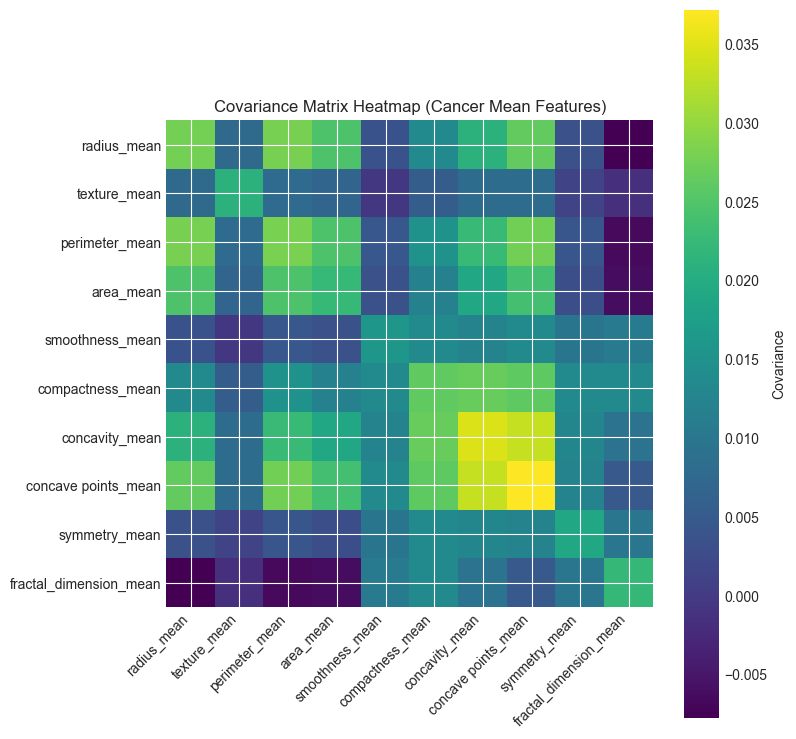

In [10]:
# YOUR CODE HERE
cov_mat = cancer_x.cov()
print('Covariance matrix shape:', cov_mat.shape)

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(cov_mat, cmap='viridis')
ax.set_title('Covariance Matrix Heatmap (Cancer Mean Features)')
ax.set_xticks(np.arange(len(cov_mat.columns)))
ax.set_yticks(np.arange(len(cov_mat.columns)))
ax.set_xticklabels(cov_mat.columns)
ax.set_yticklabels(cov_mat.columns)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
plt.colorbar(im, ax=ax, label='Covariance')
plt.tight_layout()
plt.show()

### 2b. Questions

**Question 1:** What interpretations can you draw from this covariance matrix?


**Answer 1:**

The covariance matrix shows clear groups of variables that change together.

- `radius_mean`, `perimeter_mean`, and `area_mean` have strong positive covariance with each other, which makes sense because they all measure tumor size.
- `concavity_mean` and `concave points_mean` also covary strongly (the largest absolute covariance pair in this matrix), showing these shape-irregularity features are tightly related.
- `fractal_dimension_mean` has weaker and sometimes negative covariance with some size-related features, suggesting it captures a different aspect of morphology.

Overall, the matrix indicates substantial redundancy/correlation among features, which is exactly why PCA is useful here.


### 2c. Performing PCA

Use Sci-kit Learn's [PCA class](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html) to apply PCA to the cancer dataset.

1. Create an instance of the PCA class with 2 components. _This means that we will reduce the dimensionality of the cancer dataset from 10-D to 2-D_.
2. Call the method `fit_transform` with `cancer_x` as the X parameter and saving the results into a new variable representing the transformed values.
3. Print the shape of the transformed values. The transformed values should have the shape `(569, 2)`.
4. Print the first 5 rows of the transformed data.


In [14]:
from sklearn.decomposition import PCA

In [15]:
# YOUR CODE HERE
pca_model = PCA(n_components=2)
transformed_data = pca_model.fit_transform(cancer_x)

print('PCA-transformed data shape:', transformed_data.shape)
print('Transformed data:')
print(transformed_data[:5])

print('''
-------------------------------------
Your results should look like this:
-------------------------------------
PCA-transformed data shape: (569, 2)
Transformed data:
[[ 0.89009  0.51092]
 [ 0.30381 -0.39424]
 [ 0.67735 -0.07657]
 [ 0.53311  1.05071]
 [ 0.56301 -0.19896]]
-------------------------------------
''')

PCA-transformed data shape: (569, 2)
Transformed data:
[[ 0.89009  0.51092]
 [ 0.30381 -0.39424]
 [ 0.67735 -0.07657]
 [ 0.53311  1.05071]
 [ 0.56301 -0.19896]]

-------------------------------------
Your results should look like this:
-------------------------------------
PCA-transformed data shape: (569, 2)
Transformed data:
[[ 0.89009  0.51092]
 [ 0.30381 -0.39424]
 [ 0.67735 -0.07657]
 [ 0.53311  1.05071]
 [ 0.56301 -0.19896]]
-------------------------------------



### 2d. Graph a scatter plot of the transformed data

Graph a scatter plot of the transformed data using [plt.scatter](https://matplotlib.org/3.3.3/api/_as_gen/matplotlib.axes.Axes.scatter.html)

1. Scatter Parameters
   1. Graph the first principle component on the x axis (first column of the tranformed data)
   2. Graph the second principle component on the y axis (second column of the tranformed data)
   3. Use the `cancer_y` series for the color with a black edgecolor
2. Include a title, and axis labels.
3. Add a custom [legend](https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#creating-artists-specifically-for-adding-to-the-legend-aka-proxy-artists) using mpatches.
   1. Create 1 patch with the `color` keyword argument set to whatever named color string you set for malignant
   1. Create 1 patch with the `color` keyword argument set to whatever named color string you set for benign


In [ ]:
import matplotlib.patches as mpatches

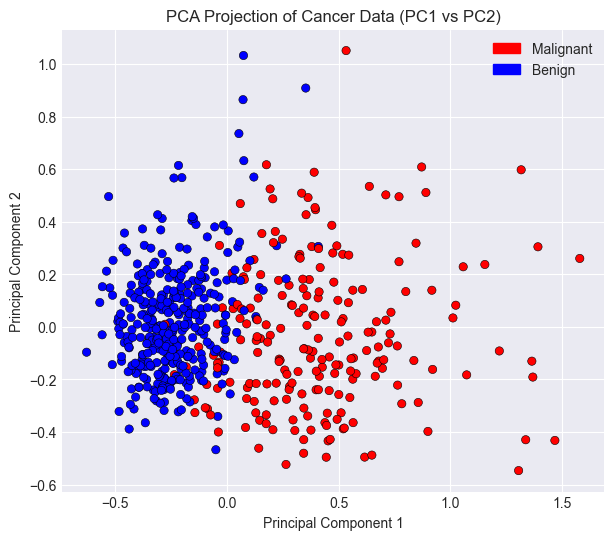

In [18]:
# YOUR CODE HERE
import matplotlib.patches as mpatches

plt.figure(figsize=(7, 6))
plt.scatter(transformed_data[:, 0], transformed_data[:, 1], c=cancer_y, edgecolors='black', linewidths=0.4)
plt.title('PCA Projection of Cancer Data (PC1 vs PC2)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

malignant_patch = mpatches.Patch(color='red', label='Malignant')
benign_patch = mpatches.Patch(color='blue', label='Benign')
plt.legend(handles=[malignant_patch, benign_patch])
plt.show()

### 2d. Visualize the PCA loadings

In PCA, the **loadings** refer to the numbers that make up the principal component vectors (i.e. the eigenvectors). The shape of the loadings (eigenvectors) are `(k, M)` where `k` is the number of PCs and `M` is the number of original variables in the dataset. This task focuses on visualizing and interpreting what the loadings mean.

1. Print out the shape of the loadings. The [PCA class](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html) of Scikit-learn stores these as a field called `components_`.
2. Use [imshow](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.imshow.html) to make a heatmap of the loadings. You should plot the **transposed** loadings, which will make your plot more readable — i.e. your heatmap should be taller than it is wide.
   1. Include a title.
   2. Set the `xticks`, `yticks`, `xticklabels` and `ytickslabels`. The y tick labels (rows) should show the original 10 variable names. The 2 x tick labels should be labeled with `'PC1'` and `'PC2'`.
   3. Use an perceptually uniform **diverging** [colormap](https://matplotlib.org/tutorials/colors/colormaps.html). Set it using the `cmap` parameter for `imshow`.
   4. To ensure that 0 is indicated by the neutral/middle color in the colormap, we need the data to be color-mapped using a range that is centered on zero. Compute the magnitude of the loadings (the maximim absolute loading). If you store that magnitude in a variable, named `mag`, then you can add the parameter and value to the imshow call: `norm=matplotlib.colors.Normalize(-mag,mag)`.
   5. Include a `colorbar`. This can be achieved by assigning a variable to your `imshow` call and then passing in that variable as a parameter to `plt.colorbar`. If that does not work, the [this example code](https://matplotlib.org/stable/gallery/images_contours_and_fields/image_annotated_heatmap.html#using-the-helper-function-code-style) may be helpful.


Loadings shape: (2, 10)


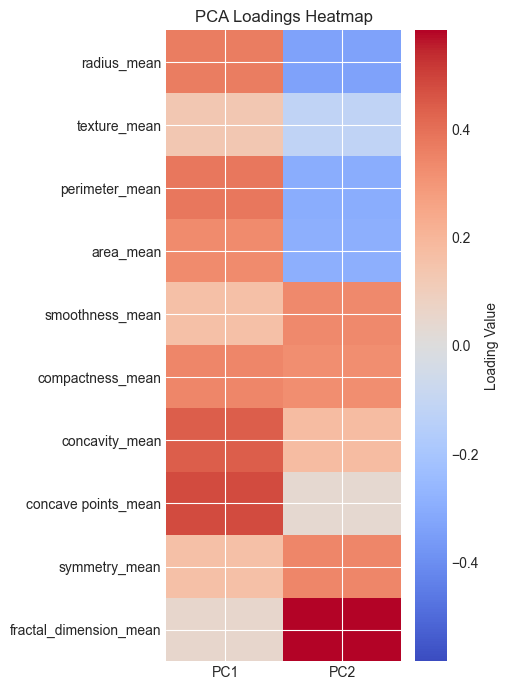

In [17]:
# YOUR CODE HERE
loadings = pca_model.components_
print('Loadings shape:', loadings.shape)

mag = np.abs(loadings).max()
fig, ax = plt.subplots(figsize=(5, 7))
im = ax.imshow(
    loadings.T,
    cmap='coolwarm',
    norm=matplotlib.colors.Normalize(-mag, mag),
    aspect='auto'
)
ax.set_title('PCA Loadings Heatmap')
ax.set_xticks([0, 1])
ax.set_xticklabels(['PC1', 'PC2'])
ax.set_yticks(np.arange(len(cancer_x.columns)))
ax.set_yticklabels(cancer_x.columns)
plt.colorbar(im, ax=ax, label='Loading Value')
plt.tight_layout()
plt.show()

### 2e. Questions

**Question 2:** Interpret the loadings of PC1 and PC2. Which variables in the cancer dataset are most positively and negatively correlated with each PC?


**Answer 2:**

From the loadings heatmap:

- **PC1** is dominated by positive loadings on size/shape-intensity features, especially `concave points_mean` (largest positive loading), with `concavity_mean`, `perimeter_mean`, `radius_mean`, and `area_mean` also strongly positive. This means higher PC1 scores correspond to larger, more irregular tumors.
- **PC2** is most positively correlated with `fractal_dimension_mean` (largest positive loading), and also with `smoothness_mean`/`symmetry_mean`. It is most negatively correlated with `radius_mean` (largest negative loading), with other size-related variables also somewhat negative.

So PC1 mostly captures a "size/irregularity" direction, while PC2 contrasts texture/fractal-like shape complexity against size-related features.


## Turn in your lab

Follow the usual submission format and submit your lab on Google Classroom.
